# Data Cleaning and Statistical Imputation – Fashion Dataset

## Objective

The objective of this notebook is to inspect, clean, and statistically impute missing values in the Fashion Products dataset before using it in a Retrieval-Augmented Generation (RAG) system.

Since vector databases such as Weaviate require JSON-compliant data, it is necessary to remove NaN values and ensure that all fields contain valid entries.

---

# 1. Dataset Inspection

The dataset was first loaded and inspected using pandas to understand the structure, variable types, and missing values.

### Data Types

The dataset contains both categorical and numerical variables.

Categorical variables:

- gender  
- masterCategory  
- subCategory  
- articleType  
- baseColour  
- season  
- usage  
- productDisplayName  

Numerical variables:

- year  
- price  
- product_id  

This classification guided the appropriate statistical treatment for missing values.

---

# 2. Missing Value Analysis

Missing values were identified using:


df.isna().sum()


Results showed missing values only in the following columns:

| Variable | Missing values |
|--------|--------|
| baseColour | 15 |
| productDisplayName | 7 |
| year | 1 |

Given the dataset size (~44k observations), the proportion of missing values was very small. However, imputation was required to ensure data consistency and JSON compatibility.

---

# 3. Statistical Imputation of `baseColour`

Since baseColour is a categorical variable, its imputation required analyzing its dependencies with other categorical variables.

## Dependency Analysis

Two statistical methods were used:

### Chi-Square Test of Independence

The Chi-Square test was applied to determine whether baseColour depends on other categorical variables such as:

- gender  
- masterCategory  
- subCategory  
- articleType  
- season  
- usage  

The p-values obtained were approximately zero, indicating statistically significant relationships.

### Cramér’s V

To measure the strength of association, Cramér’s V was computed.

Results indicated moderate dependencies, particularly with:

- gender  
- masterCategory  
- articleType  

## Hierarchical Imputation

Missing baseColour values were filled using hierarchical conditional imputation based on the most relevant variables:

(gender, masterCategory, articleType)

The missing color was replaced by the most frequent value (mode) observed within each group combination.

This strategy preserves the semantic consistency of product attributes.

---

# 4. Imputation of `productDisplayName`

productDisplayName is a textual categorical variable describing the product.

Inspection showed that missing values occurred in rows where other descriptive attributes were still available, such as:

- gender  
- baseColour  
- articleType  

Instead of replacing missing values with a generic placeholder, the product names were reconstructed using a semantic combination of these attributes.

Example:

Women Maroon Clutches  
Men Black Perfume and Body Mist

This approach ensures the column remains informative for downstream NLP tasks and embedding generation.

---

# 5. Statistical Analysis of `year`

The variable year is numerical and required a distribution analysis.

### Descriptive Statistics

- Mean ≈ 2012.8  
- Median = 2012  
- Standard deviation ≈ 2.1  
- Range: 2007 – 2019  

### Distribution Analysis

Histogram and boxplot visualizations showed:

- a relatively symmetric distribution  
- no extreme outliers  
- most values concentrated between 2011 and 2013

### Dependency Test

An ANOVA test was performed to determine whether the year depends on the articleType.

The p-value obtained was approximately zero, indicating a statistical dependency.

However, since only one value was missing, a global median imputation was considered statistically sufficient and robust.

---

# 6. Final Dataset Validation

After applying all imputations, the dataset was validated using:


df.isna().sum()


The result confirmed that no missing values remained.

The dataset is now:

- complete  
- statistically consistent  
- JSON compliant  

---

# 7. Dataset Export

Finally, the cleaned dataset was converted to a list of dictionaries and saved using joblib:


joblib.dump(clean_data, "clothes_json.joblib")

This dataset will be used for ingestion into the vector database powering the Fashion RAG assistant.

In [1]:
! pip install pandas joblib numpy

In [2]:
import joblib
import pandas as pd
import numpy as np

data = joblib.load(r"D:\inspectdata\clothes_json.joblib")

df = pd.DataFrame(data)

print(df.shape)
df.head()

(44424, 11)


,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,price,product_id
0,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt,67.0,15970
1,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans,22.0,39386
2,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch,150.0,59263
3,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants,135.0,21379
4,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt,124.0,53759


In [3]:
df.dtypes

gender                 object
masterCategory         object
subCategory            object
articleType            object
baseColour             object
season                 object
year                  float64
usage                  object
productDisplayName     object
price                 float64
product_id              int64
dtype: object

In [4]:
nan_counts = df.isna().sum().sort_values(ascending=False)

nan_counts

baseColour            15
productDisplayName     7
year                   1
gender                 0
masterCategory         0
subCategory            0
articleType            0
season                 0
usage                  0
price                  0
product_id             0
dtype: int64

In [5]:
nan_percent = (df.isna().mean() * 100).sort_values(ascending=False)

nan_percent

baseColour            0.033766
productDisplayName    0.015757
year                  0.002251
gender                0.000000
masterCategory        0.000000
subCategory           0.000000
articleType           0.000000
season                0.000000
usage                 0.000000
price                 0.000000
product_id            0.000000
dtype: float64

In [6]:
inf_counts = np.isinf(df.select_dtypes(include=[np.number])).sum()

inf_counts

year          0
price         0
product_id    0
dtype: int64

In [7]:
df.describe()

,year,price,product_id
count,44423.000000,44424.000000,44424.000000
mean,2012.806497,154.920561,29696.334301
std,2.126480,83.934064,17049.490518
min,2007.000000,10.000000,1163.000000
25%,2011.000000,82.000000,14768.750000
50%,2012.000000,155.000000,28618.500000
75%,2015.000000,227.000000,44683.250000
max,2019.000000,300.000000,60000.000000


In [8]:
df[df.isna().any(axis=1)]

,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,price,product_id
3677,Women,Accessories,Bags,Clutches,Maroon,Summer,2012.0,Casual,NaN,106.0,42878
6206,Men,Apparel,Bottomwear,Jeans,NaN,Fall,2016.0,Casual,Wrangler Men Blue Texas Jeans,29.0,11293
9516,Men,Apparel,Bottomwear,Jeans,NaN,Fall,2016.0,Casual,Wrangler Men Black Texas Jeans,53.0,41347
12763,Men,Apparel,Bottomwear,Jeans,NaN,Fall,2016.0,Casual,Wrangler Men Blue Texas Jeans,106.0,11288
14291,Women,Personal Care,Fragrance,Perfume and Body Mist,NaN,Spring,2017.0,All occasions,NaN,239.0,30991
15526,Women,Personal Care,Skin,Face Moisturisers,NaN,Spring,2017.0,Casual,Lotus Herbals Quincenourish Quince Seed Nouris...,211.0,57698
15708,Men,Apparel,Bottomwear,Jeans,NaN,Fall,2016.0,Casual,Wrangler Men Blue Millard Jeans,250.0,41355
17268,Men,Personal Care,Fragrance,Perfume and Body Mist,NaN,Spring,2017.0,All occasions,GUESS Man Eau De Toilette 75 ml,288.0,43122
17639,Men,Personal Care,Fragrance,Perfume and Body Mist,NaN,Spring,2017.0,All occasions,NaN,197.0,45687
20209,Men,Apparel,Bottomwear,Jeans,NaN,Fall,2016.0,Casual,Wrangler Men Blue Floyd Jeans,193.0,11309


In [9]:
df["baseColour"].value_counts()

Black                9728
White                5538
Blue                 4918
Brown                3494
Grey                 2741
Red                  2455
Green                2115
Pink                 1860
Navy Blue            1789
Purple               1640
Silver               1090
Yellow                778
Beige                 749
Gold                  628
Maroon                581
Orange                530
Olive                 410
Multi                 394
Cream                 390
Steel                 315
Charcoal              228
Peach                 195
Off White             182
Skin                  179
Lavender              162
Grey Melange          146
Khaki                 139
Magenta               129
Teal                  120
Tan                   114
Mustard                97
Bronze                 95
Copper                 86
Turquoise Blue         69
Rust                   66
Burgundy               45
Metallic               43
Coffee Brown           31
Mauve       

In [10]:
df["baseColour"].value_counts(normalize=True)

Black                0.219055
White                0.124704
Blue                 0.110743
Brown                0.078678
Grey                 0.061722
Red                  0.055282
Green                0.047625
Pink                 0.041883
Navy Blue            0.040285
Purple               0.036929
Silver               0.024545
Yellow               0.017519
Beige                0.016866
Gold                 0.014141
Maroon               0.013083
Orange               0.011935
Olive                0.009232
Multi                0.008872
Cream                0.008782
Steel                0.007093
Charcoal             0.005134
Peach                0.004391
Off White            0.004098
Skin                 0.004031
Lavender             0.003648
Grey Melange         0.003288
Khaki                0.003130
Magenta              0.002905
Teal                 0.002702
Tan                  0.002567
Mustard              0.002184
Bronze               0.002139
Copper               0.001937
Turquoise 

In [12]:
from scipy.stats import chi2_contingency
import pandas as pd

target = "baseColour"

categorical_cols = [
    "gender",
    "masterCategory",
    "subCategory",
    "articleType",
    "season",
    "usage"
]

results = []

for col in categorical_cols:
    
    contingency_table = pd.crosstab(df[col], df[target])
    
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    
    results.append({
        "variable": col,
        "p_value": p
    })

results_df = pd.DataFrame(results).sort_values("p_value")

results_df

,variable,p_value
0,gender,0.0
1,masterCategory,0.0
2,subCategory,0.0
3,articleType,0.0
4,season,0.0
5,usage,0.0


In [13]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

def cramers_v(x, y):

    contingency_table = pd.crosstab(x, y)

    chi2 = chi2_contingency(contingency_table)[0]

    n = contingency_table.sum().sum()

    r, k = contingency_table.shape

    return np.sqrt(chi2 / (n * (min(r-1, k-1))))

In [14]:
categorical_cols = [
    "gender",
    "masterCategory",
    "subCategory",
    "articleType",
    "season",
    "usage"
]

for col in categorical_cols:
    
    print(col, cramers_v(df[col], df["baseColour"]))

gender 0.21814449173160785
masterCategory 0.2237895348076108
subCategory 0.17342209367745734
articleType 0.22116084075664208
season 0.18598796744476623
usage 0.13839134505235015


In [15]:
import numpy as np

# niveau 1
df["baseColour"] = df.groupby(
    ["gender","masterCategory","articleType"]
)["baseColour"].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan)
)

In [16]:
df["baseColour"].isna().sum()

0

In [17]:
df[df["productDisplayName"].isna()]

,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,price,product_id
3677,Women,Accessories,Bags,Clutches,Maroon,Summer,2012.0,Casual,NaN,106.0,42878
14291,Women,Personal Care,Fragrance,Perfume and Body Mist,White,Spring,2017.0,All occasions,NaN,239.0,30991
17639,Men,Personal Care,Fragrance,Perfume and Body Mist,Black,Spring,2017.0,All occasions,NaN,197.0,45687
22089,Women,Accessories,Bags,Clutches,Brown,Summer,2012.0,Casual,NaN,264.0,42863
23484,Women,Personal Care,Fragrance,Perfume and Body Mist,White,Spring,2017.0,All occasions,NaN,175.0,45698
37531,Men,Personal Care,Fragrance,Perfume and Body Mist,Black,Spring,2017.0,All occasions,NaN,169.0,30992
40675,Men,Personal Care,Fragrance,Perfume and Body Mist,Black,Spring,2017.0,All occasions,NaN,189.0,43119


In [18]:
df["productDisplayName"] = df["productDisplayName"].fillna(
    (df["gender"] + " " + df["baseColour"].fillna("") + " " + df["articleType"]).str.strip()
)

In [19]:
df["productDisplayName"].isna().sum()

0

In [20]:
df["year"].describe()

count    44423.000000
mean      2012.806497
std          2.126480
min       2007.000000
25%       2011.000000
50%       2012.000000
75%       2015.000000
max       2019.000000
Name: year, dtype: float64

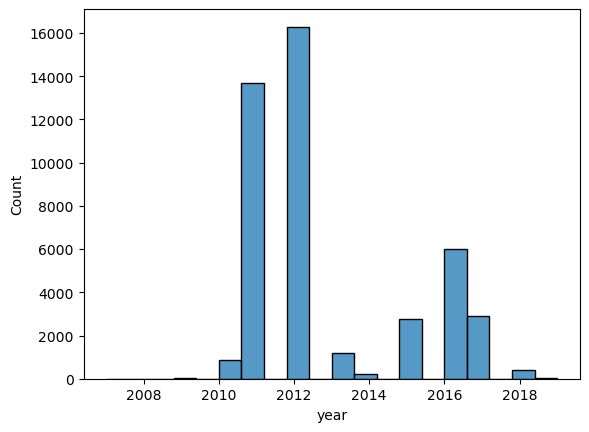

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["year"], bins=20)
plt.show()

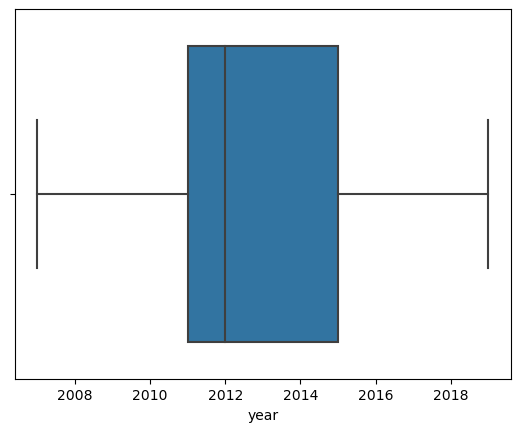

In [22]:
sns.boxplot(x=df["year"])
plt.show()

In [23]:
from scipy.stats import f_oneway

groups = [group["year"].dropna().values for name, group in df.groupby("articleType")]

f_stat, p_value = f_oneway(*groups)

print("p-value:", p_value)

p-value: 0.0


In [25]:
df["year"] = df["year"].fillna(df["year"].median())

In [26]:
df.isna().sum()

gender                0
masterCategory        0
subCategory           0
articleType           0
baseColour            0
season                0
year                  0
usage                 0
productDisplayName    0
price                 0
product_id            0
dtype: int64

In [27]:
clean_data = df.to_dict(orient="records")

In [28]:
joblib.dump(clean_data, r"D:\inspectdata\clothes_json1.joblib")

['D:\\inspectdata\\clothes_json1.joblib']

In [29]:
joblib.dump(clean_data, r"D:\inspectdata\clothes_json1.joblib")

['D:\\inspectdata\\clothes_json1.joblib']

In [30]:
data = joblib.load(r"D:\inspectdata\clothes_json1.joblib")

print(type(data))
print(len(data))
print(data[0])

<class 'list'>
44424
{'gender': 'Men', 'masterCategory': 'Apparel', 'subCategory': 'Topwear', 'articleType': 'Shirts', 'baseColour': 'Navy Blue', 'season': 'Fall', 'year': 2011.0, 'usage': 'Casual', 'productDisplayName': 'Turtle Check Men Navy Blue Shirt', 'price': 67.0, 'product_id': 15970}
